# Chapter 2: Data Understanding & Preprocessing

**Objective:** This notebook performs comprehensive exploratory data analysis (EDA) and preprocessing on the credit scoring dataset to prepare it for machine learning modeling.

**Dataset:** Credit Scoring Dataset (cs-training.csv)

**Key Steps:**
1. Data Loading & Initial Inspection
2. Exploratory Data Analysis (Univariate, Bivariate, Multivariate)
3. Data Quality Assessment (Missing Values, Outliers, Dirty Data)
4. Data Cleaning & Preprocessing
5. Feature Engineering
6. Feature Selection

---

## 1. Import Required Libraries

We'll use the following libraries:
- **pandas**: Data manipulation and analysis
- **numpy**: Numerical computing
- **matplotlib**: Basic plotting
- **seaborn**: Statistical data visualization

In [1]:
!pip install pandas numpy matplotlib seaborn

In [2]:
# Import libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define consistent color palette - Modern Purple & Teal theme
COLORS = {
    'primary': '#6366f1',      # Indigo - main color
    'secondary': '#06b6d4',    # Cyan - secondary color
    'accent': '#f43f5e',       # Rose - accent/highlight
    'success': '#10b981',      # Emerald - positive values
    'warning': '#f59e0b',      # Amber - warnings
    'no_default': '#6366f1',   # Indigo - no default class
    'default': '#f43f5e',      # Rose - default class
    'positive_corr': '#f43f5e', # Rose - positive correlation
    'negative_corr': '#06b6d4', # Cyan - negative correlation
    'outlier': '#f59e0b',      # Amber - outliers
    'missing': '#f43f5e'       # Rose - missing values
}

# Set visualization style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'

# Display all columns in pandas output
pd.set_option('display.max_columns', None)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


---
## 2. Data Loading & Initial Inspection

Load the credit scoring dataset and perform initial exploration to understand its structure.

In [3]:
# Load the credit scoring training dataset
df = pd.read_csv("cs-training.csv")

print("✓ Dataset loaded successfully")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✓ Dataset loaded successfully
Dataset shape: 150,000 rows × 12 columns


In [4]:
# Remove the unwanted index column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)
    print("✓ Unwanted index column removed")
else:
    print("✓ No unwanted index column found")

print(f"Updated shape: {df.shape}")

✓ Unwanted index column removed
Updated shape: (150000, 11)


In [5]:
# Display the first few rows to understand the data structure
print("\n First 5 Rows of the Dataset ")
print(df.head())


 First 5 Rows of the Dataset 
   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0                 1                              0.766127   45   
1                 0                              0.957151   40   
2                 0                              0.658180   38   
3                 0                              0.233810   30   
4                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                        0   
1                              

In [6]:
# Display all column names for reference
print("\n Dataset Columns :  ")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")
print(f"\nTotal columns: {len(df.columns)}")


 Dataset Columns :  
  1. SeriousDlqin2yrs
  2. RevolvingUtilizationOfUnsecuredLines
  3. age
  4. NumberOfTime30-59DaysPastDueNotWorse
  5. DebtRatio
  6. MonthlyIncome
  7. NumberOfOpenCreditLinesAndLoans
  8. NumberOfTimes90DaysLate
  9. NumberRealEstateLoansOrLines
  10. NumberOfTime60-89DaysPastDueNotWorse
  11. NumberOfDependents

Total columns: 11


In [7]:
# Create column mapping to Pascal_Case with underscores
column_mapping = {
    'SeriousDlqin2yrs': 'Serious_Dlq_In_2Yrs',
    'RevolvingUtilizationOfUnsecuredLines': 'Revolving_Utilization_Of_Unsecured_Lines',
    'age': 'Age',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Number_Of_Time_30_59_Days_Past_Due',
    'DebtRatio': 'Debt_Ratio',
    'MonthlyIncome': 'Monthly_Income',
    'NumberOfOpenCreditLinesAndLoans': 'Number_Of_Open_Credit_Lines_And_Loans',
    'NumberOfTimes90DaysLate': 'Number_Of_Times_90_Days_Late',
    'NumberRealEstateLoansOrLines': 'Number_Real_Estate_Loans_Or_Lines',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Number_Of_Time_60_89_Days_Past_Due',
    'NumberOfDependents': 'Number_Of_Dependents'
}

# Show before
print(" BEFORE Renaming ")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print("\n" + "-"*55 + "\n")

# Apply renaming (only for columns that exist)
rename_dict = {k: v for k, v in column_mapping.items() if k in df.columns}
df = df.rename(columns=rename_dict)

# Show after
print(" AFTER Renaming ")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n✓ {len(rename_dict)} columns renamed successfully")

 BEFORE Renaming 
   1. SeriousDlqin2yrs
   2. RevolvingUtilizationOfUnsecuredLines
   3. age
   4. NumberOfTime30-59DaysPastDueNotWorse
   5. DebtRatio
   6. MonthlyIncome
   7. NumberOfOpenCreditLinesAndLoans
   8. NumberOfTimes90DaysLate
   9. NumberRealEstateLoansOrLines
  10. NumberOfTime60-89DaysPastDueNotWorse
  11. NumberOfDependents

-------------------------------------------------------

 AFTER Renaming 
   1. Serious_Dlq_In_2Yrs
   2. Revolving_Utilization_Of_Unsecured_Lines
   3. Age
   4. Number_Of_Time_30_59_Days_Past_Due
   5. Debt_Ratio
   6. Monthly_Income
   7. Number_Of_Open_Credit_Lines_And_Loans
   8. Number_Of_Times_90_Days_Late
   9. Number_Real_Estate_Loans_Or_Lines
  10. Number_Of_Time_60_89_Days_Past_Due
  11. Number_Of_Dependents

✓ 11 columns renamed successfully


---
## 3. Exploratory Data Analysis (EDA)

We'll perform three types of analysis:
- **Univariate**: Analysis of individual variables
- **Bivariate**: Relationships between two variables
- **Multivariate**: Relationships among multiple variables

### 3.1 Univariate Analysis

In [8]:
# Generate comprehensive statistical summary of all numerical features
# This includes: count, mean, std, min, quartiles (25%, 50%, 75%), and max
print("\nStatistical Summary ")
print(df.describe())


Statistical Summary 
       Serious_Dlq_In_2Yrs  Revolving_Utilization_Of_Unsecured_Lines  \
count        150000.000000                             150000.000000   
mean              0.066840                                  6.048438   
std               0.249746                                249.755371   
min               0.000000                                  0.000000   
25%               0.000000                                  0.029867   
50%               0.000000                                  0.154181   
75%               0.000000                                  0.559046   
max               1.000000                              50708.000000   

                 Age  Number_Of_Time_30_59_Days_Past_Due     Debt_Ratio  \
count  150000.000000                       150000.000000  150000.000000   
mean       52.295207                            0.421033     353.005076   
std        14.771866                            4.192781    2037.818523   
min         0.000000         

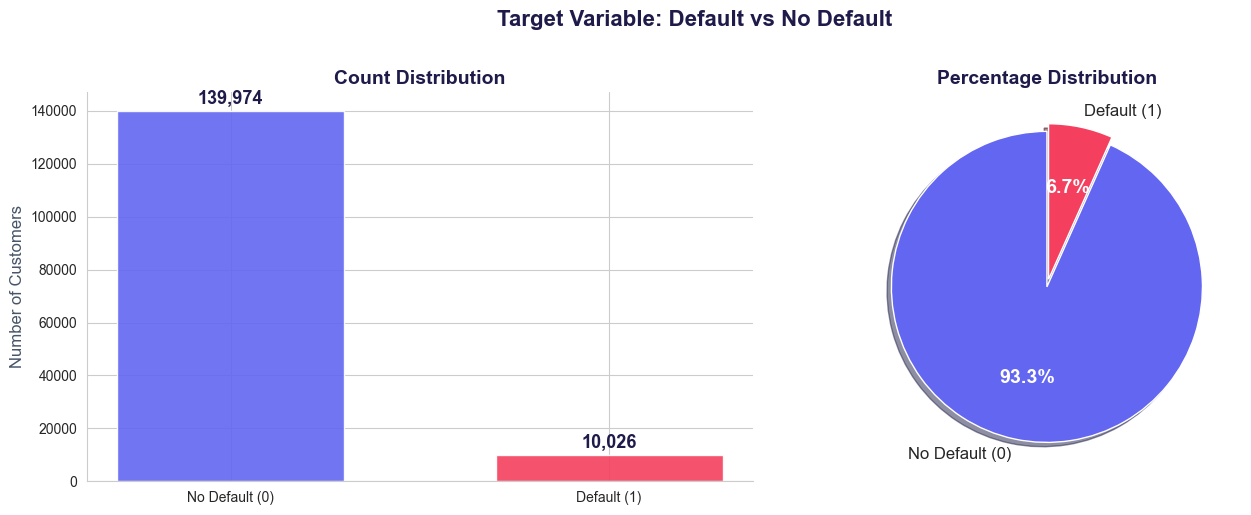


 Target Variable Distribution 
Serious_Dlq_In_2Yrs
0    139974
1     10026
Name: count, dtype: int64

Percentage Distribution:
Serious_Dlq_In_2Yrs
0    93.316
1     6.684
Name: proportion, dtype: float64

⚠️ Imbalance Ratio: 14.0:1


In [9]:
# Find target column dynamically
target_col = [col for col in df.columns if 'Serious_Dlq' in col or 'Dlq' in col]
if not target_col:
    target_col = [df.columns[0]]
target_col = target_col[0]

# Get value counts
value_counts = df[target_col].value_counts()
labels = ['No Default (0)', 'Default (1)']
colors = [COLORS['no_default'], COLORS['default']]

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- SUBPLOT 1: Bar Chart ----
bars = axes[0].bar(labels, value_counts.values, color=colors, 
                   edgecolor='white', alpha=0.9, width=0.6)

# Add value labels on bars
for bar, val in zip(bars, value_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', 
                 fontsize=13, color='#1e1b4b')

axes[0].set_title('Count Distribution', fontsize=14, fontweight='bold', color='#1e1b4b')
axes[0].set_ylabel('Number of Customers', fontsize=12, color='#475569')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ---- SUBPLOT 2: Pie Chart ----
percentages = value_counts.values / value_counts.values.sum() * 100
explode = (0, 0.05)

wedges, texts, autotexts = axes[1].pie(
    percentages, 
    labels=labels, 
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 12}
)

# Style the percentage text
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(14)
    autotext.set_color('white')

axes[1].set_title('Percentage Distribution', fontsize=14, fontweight='bold', color='#1e1b4b')

# Main title
fig.suptitle('Target Variable: Default vs No Default', 
             fontsize=16, fontweight='bold', color='#1e1b4b', y=1.02)

plt.tight_layout()
plt.show()

# Print text summary
print("\n Target Variable Distribution ")
print(value_counts)
print("\nPercentage Distribution:")
print(df[target_col].value_counts(normalize=True) * 100)

# Imbalance ratio
imbalance_ratio = value_counts.iloc[0] / value_counts.iloc[1]
print(f"\n⚠️ Imbalance Ratio: {imbalance_ratio:.1f}:1")

### 3.2 Bivariate Analysis

Analyze relationships between individual features and the target variable to identify patterns.

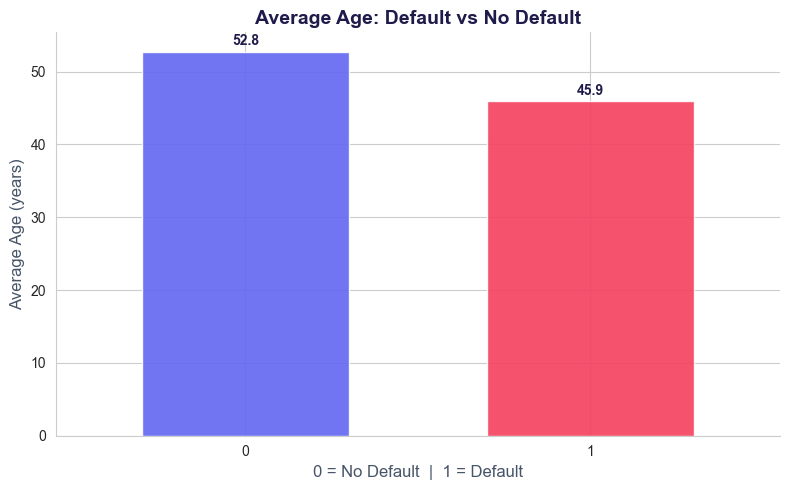


📊 INSIGHT: Analyze if there's a significant age difference between groups


In [10]:
# Dynamically find the age column using a generic substring
age_col = [col for col in df.columns if 'age' in col.lower()]
if not age_col:
    raise ValueError("Could not find age column in dataset")
age_col = age_col[0]

# Compare average age between defaulters and non-defaulters
plt.figure(figsize=(8, 5))
age_means = df.groupby(target_col)[age_col].mean()
age_means.plot(
    kind="bar", 
    color=[COLORS['no_default'], COLORS['default']], 
    edgecolor='white',
    alpha=0.9,
    width=0.6
)
plt.title("Average Age: Default vs No Default", fontsize=14, fontweight='bold', color='#1e1b4b')
plt.xlabel("0 = No Default  |  1 = Default", fontsize=12, color='#475569')
plt.ylabel("Average Age (years)", fontsize=12, color='#475569')
plt.xticks(rotation=0)

# Add value labels
for i, v in enumerate(age_means):
    plt.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', 
             fontweight='bold', color='#1e1b4b')

# FIX: Use plt.gca() to access the current axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT: Analyze if there's a significant age difference between groups")

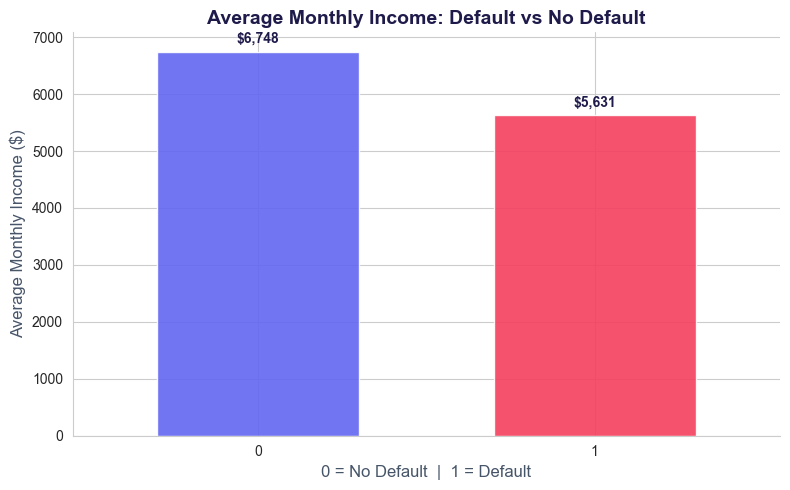


📊 INSIGHT: Check if income level influences default probability


In [11]:
# Dynamically find the income column using a generic substring
income_col = [col for col in df.columns if 'income' in col.lower()]
if not income_col:
    raise ValueError("Could not find income column in dataset")
income_col = income_col[0]

# Compare average monthly income between defaulters and non-defaulters
plt.figure(figsize=(8, 5))
income_means = df.groupby(target_col)[income_col].mean()
income_means.plot(
    kind="bar", 
    color=[COLORS['no_default'], COLORS['default']], 
    edgecolor='white',
    alpha=0.9,
    width=0.6
)
plt.title("Average Monthly Income: Default vs No Default", 
          fontsize=14, fontweight='bold', color='#1e1b4b')
plt.xlabel("0 = No Default  |  1 = Default", fontsize=12, color='#475569')
plt.ylabel("Average Monthly Income ($)", fontsize=12, color='#475569')
plt.xticks(rotation=0)

# Add value labels
for i, v in enumerate(income_means):
    plt.text(i, v + 100, f'${v:,.0f}', ha='center', va='bottom', 
             fontweight='bold', color='#1e1b4b')

# FIX: Use plt.gca() to access the current axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT: Check if income level influences default probability")

### 3.3 Multivariate Analysis

Examine correlations between all features and the target variable to identify the most predictive features.

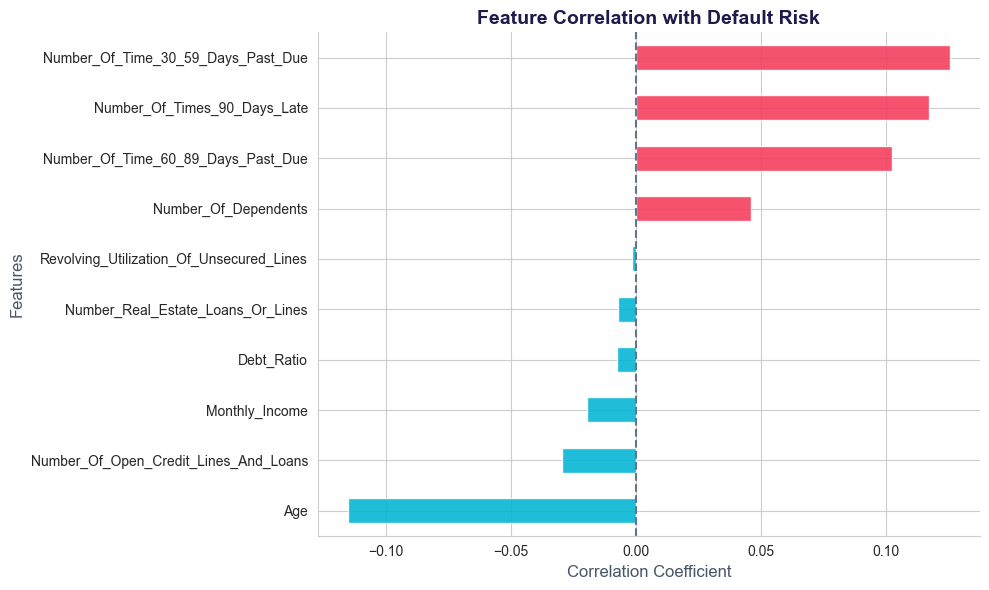


📊 INTERPRETATION GUIDE:
   → Positive correlation (Rose bars): Higher values → Higher default risk
   → Negative correlation (Cyan bars): Higher values → Lower default risk
   → Correlation closer to ±1: Stronger relationship
   → Correlation closer to 0: Weaker relationship

📈 Top Positive Correlations (increase default risk):
Number_Of_Time_30_59_Days_Past_Due    0.125587
Number_Of_Times_90_Days_Late          0.117175
Number_Of_Time_60_89_Days_Past_Due    0.102261
Number_Of_Dependents                  0.046048
Name: Serious_Dlq_In_2Yrs, dtype: float64

📉 Top Negative Correlations (decrease default risk):
Age                                        -0.115386
Number_Of_Open_Credit_Lines_And_Loans      -0.029669
Monthly_Income                             -0.019746
Debt_Ratio                                 -0.007602
Number_Real_Estate_Loans_Or_Lines          -0.007038
Revolving_Utilization_Of_Unsecured_Lines   -0.001802
Name: Serious_Dlq_In_2Yrs, dtype: float64


In [12]:
# Calculate correlation between each feature and the target variable
corr = df.corr()[target_col].drop(target_col).sort_values()

# Visualize correlations
plt.figure(figsize=(10, 6))
colors = [COLORS['positive_corr'] if x > 0 else COLORS['negative_corr'] for x in corr]
corr.plot(kind="barh", color=colors, edgecolor='white', alpha=0.9)
plt.title("Feature Correlation with Default Risk", fontsize=14, fontweight='bold', color='#1e1b4b')
plt.xlabel("Correlation Coefficient", fontsize=12, color='#475569')
plt.ylabel("Features", fontsize=12, color='#475569')
plt.axvline(x=0, color='#64748b', linewidth=1.5, linestyle='--')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\n📊 INTERPRETATION GUIDE:")
print(f"   → Positive correlation (Rose bars): Higher values → Higher default risk")
print(f"   → Negative correlation (Cyan bars): Higher values → Lower default risk")
print("   → Correlation closer to ±1: Stronger relationship")
print("   → Correlation closer to 0: Weaker relationship")

print("\n📈 Top Positive Correlations (increase default risk):")
print(corr[corr > 0].sort_values(ascending=False))

print("\n📉 Top Negative Correlations (decrease default risk):")
print(corr[corr < 0].sort_values())

---
## 4. Data Quality Assessment

Identify and analyze data quality issues that need to be addressed.

### 4.1 Missing Values Analysis


 Missing Values Summary 
                      Missing_Count  Missing_Percentage
Monthly_Income                29731           19.820667
Number_Of_Dependents           3924            2.616000


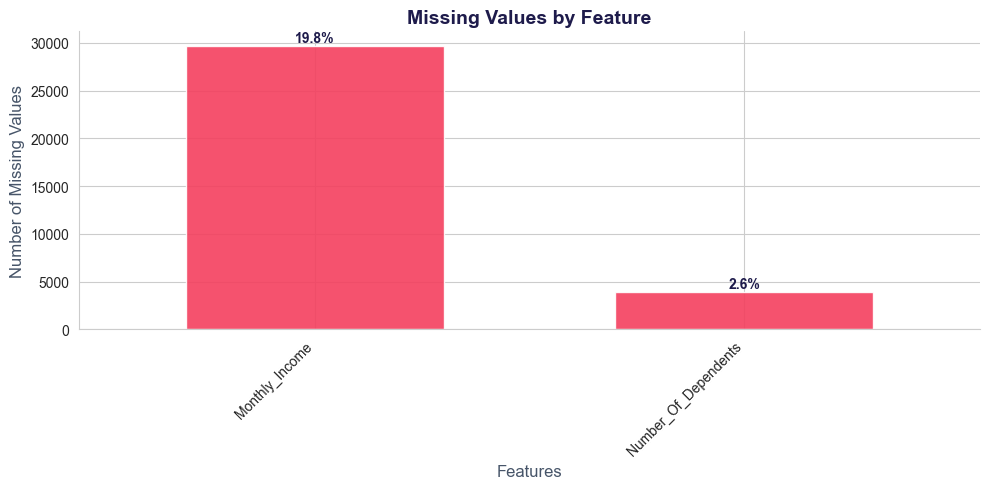

In [13]:
# Count missing values for each feature
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percentage': missing_percentage
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values(
    'Missing_Count', ascending=False
)

print("\n Missing Values Summary ")
print(missing_summary)

# Visualize missing values
if len(missing_summary) > 0:
    plt.figure(figsize=(10, 5))
    missing_data = missing_values[missing_values > 0]
    missing_data.plot(
        kind="bar", 
        color=COLORS['missing'], 
        edgecolor='white',
        alpha=0.9,
        width=0.6
    )
    plt.title("Missing Values by Feature", fontsize=14, fontweight='bold', color='#1e1b4b')
    plt.xlabel("Features", fontsize=12, color='#475569')
    plt.ylabel("Number of Missing Values", fontsize=12, color='#475569')
    plt.xticks(rotation=45, ha='right')
    
    # Add percentage labels
    for i, (idx, val) in enumerate(missing_data.items()):
        pct = (val / len(df)) * 100
        plt.text(i, val + 50, f'{pct:.1f}%', ha='center', va='bottom', 
                 fontweight='bold', color='#1e1b4b')
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values found!")

### 4.2 Outlier Detection

Use box plots to identify outliers in numerical features. Outliers can significantly impact model performance.


===== Outlier Summary Table (IQR Method) =====
                                 Feature  N outliers  % outliers  Lower bound  Upper bound
                              Debt_Ratio       31311       20.87        -0.86         1.91
      Number_Of_Time_30_59_Days_Past_Due       23982       15.99         0.00         0.00
                    Number_Of_Dependents       13336        8.89        -1.50         2.50
                     Serious_Dlq_In_2Yrs       10026        6.68         0.00         0.00
            Number_Of_Times_90_Days_Late        8338        5.56         0.00         0.00
      Number_Of_Time_60_89_Days_Past_Due        7604        5.07         0.00         0.00
                          Monthly_Income        4879        3.25     -3873.50     15522.50
   Number_Of_Open_Credit_Lines_And_Loans        3980        2.65        -4.00        20.00
       Number_Real_Estate_Loans_Or_Lines         793        0.53        -3.00         5.00
Revolving_Utilization_Of_Unsecured_Lines  

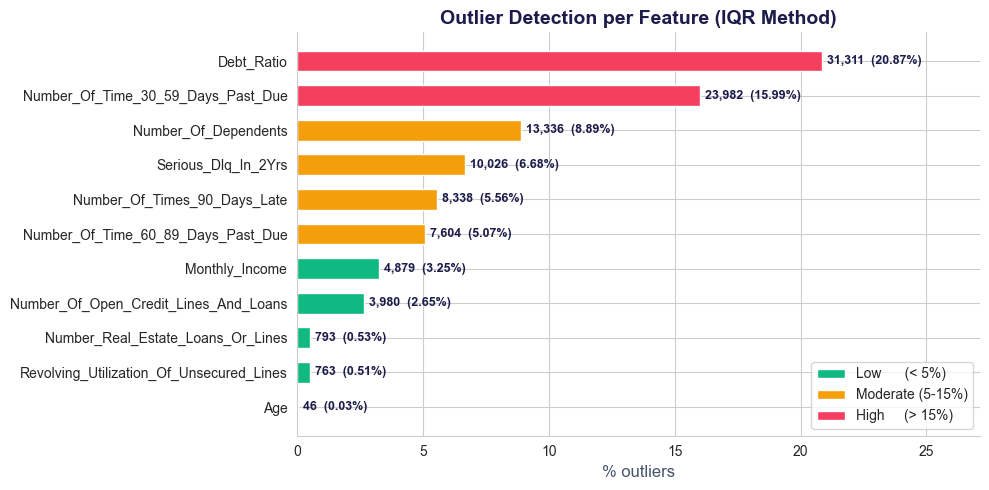

In [14]:
# Select all numerical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# IQR (Inter-Quartile Range) method:
#   Q1  = 25th percentile
#   Q3  = 75th percentile
#   IQR = Q3 - Q1
#
#   lower bound = Q1 - 1.5 * IQR
#   upper bound = Q3 + 1.5 * IQR
#
# any value outside this range is flagged as an outlier —
# same rule used by box plots
def count_outliers_iqr(series):
    Q1     = series.quantile(0.25)
    Q3     = series.quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR   # lower bound
    upper  = Q3 + 1.5 * IQR   # upper bound
    n_out  = ((series < lower) | (series > upper)).sum()
    return n_out, lower, upper

# run the check on every numeric feature
outlier_report = []
for col in num_cols:
    n_out, lo, hi = count_outliers_iqr(df[col].dropna())
    outlier_report.append({
        'Feature':     col,
        'N outliers':  n_out,
        '% outliers':  round(n_out / len(df) * 100, 2),
        'Lower bound': round(lo, 2),
        'Upper bound': round(hi, 2)
    })

outlier_df = pd.DataFrame(outlier_report).sort_values('N outliers', ascending=False)
print("\n===== Outlier Summary Table (IQR Method) =====")
print(outlier_df.to_string(index=False))

# Import Patch for the legend
from matplotlib.patches import Patch

# horizontal bar chart — color coded by severity level using our COLORS dict
fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = [
    COLORS['accent']  if p > 15 else COLORS['warning'] if p > 5 else COLORS['success']
    for p in outlier_df['% outliers']
]

bars = ax.barh(outlier_df['Feature'], outlier_df['% outliers'],
               color=bar_colors, edgecolor='white', height=0.6)

ax.set_xlabel('% outliers', fontsize=12, color='#475569')
ax.set_title('Outlier Detection per Feature (IQR Method)', 
             fontsize=14, fontweight='bold', color='#1e1b4b')
ax.invert_yaxis()
ax.set_xlim(0, outlier_df['% outliers'].max() * 1.3)

# show count and percentage on each bar
for bar, pct, n in zip(bars, outlier_df['% outliers'], outlier_df['N outliers']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{n:,}  ({pct}%)', va='center', fontsize=9, fontweight='bold', color='#1e1b4b')

# Add legend with updated colors
ax.legend(handles=[
    Patch(facecolor=COLORS['success'], label='Low      (< 5%)'),
    Patch(facecolor=COLORS['warning'], label='Moderate (5-15%)'),
    Patch(facecolor=COLORS['accent'],  label='High     (> 15%)'),
], loc='lower right')

# Apply clean styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 4.3 Dirty Data Detection

Check for data quality issues such as duplicates and invalid values.

In [15]:
# Check for various data quality issues using dynamically found columns
print("\n Data Quality Checks")

# 1. Duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\n. Duplicate Rows: {duplicate_count:,}")
if duplicate_count > 0:
    print(f"    {duplicate_count} duplicate rows detected - consider removing")
else:
    print("   ✓ No duplicates found")

# 2. Invalid age values (age should be positive) - Uses dynamic age_col
invalid_age = (df[age_col] <= 0).sum()
print(f"\n. Invalid Age Values (≤ 0): {invalid_age:,}")
if invalid_age > 0:
    print(f"    {invalid_age} records with zero or negative age")
else:
    print("   ✓ All ages are valid")

# 3. Zero monthly income - Uses dynamic income_col
zero_income = (df[income_col] == 0).sum()
print(f"\n. Zero Monthly Income: {zero_income:,}")
if zero_income > 0:
    print(f"    {zero_income} records with zero income")
else:
    print("   ✓ No zero income records")

# Summary
total_issues = duplicate_count + invalid_age + zero_income
print(f"TOTAL DATA QUALITY ISSUES DETECTED: {total_issues:,}")



 Data Quality Checks

. Duplicate Rows: 609
    609 duplicate rows detected - consider removing

. Invalid Age Values (≤ 0): 1
    1 records with zero or negative age

. Zero Monthly Income: 1,634
    1634 records with zero income
TOTAL DATA QUALITY ISSUES DETECTED: 2,244


---
## 5. Data Cleaning & Preprocessing

Now we'll clean the data based on the issues identified above.

### 5.1 Handle Missing Values

We'll use **median imputation** for missing values in numerical features. 
Median is preferred over mean because it's robust to outliers.

In [16]:
# Create a copy of the dataframe to preserve the original
df_clean = df.copy()

# Dynamically get columns with missing values
missing_cols = df_clean.isnull().sum()[df_clean.isnull().sum() > 0].index.tolist()

print(" Missing Values BEFORE Imputation ")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Impute missing values with median dynamically
for col in missing_cols:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)
    print(f"\n✓ '{col}' imputed with median value: {median_value:.2f}")

print("\n Missing Values AFTER Imputation ")
remaining_missing = df_clean.isnull().sum().sum()
print(f"Total missing values remaining: {remaining_missing}")

if remaining_missing == 0:
    print("\n SUCCESS: All missing values have been handled!")

 Missing Values BEFORE Imputation 
Monthly_Income          29731
Number_Of_Dependents     3924
dtype: int64

✓ 'Monthly_Income' imputed with median value: 5400.00

✓ 'Number_Of_Dependents' imputed with median value: 0.00

 Missing Values AFTER Imputation 
Total missing values remaining: 0

 SUCCESS: All missing values have been handled!


### 5.2 Remove Outliers

We'll use the **IQR (Interquartile Range) method** to remove outliers.

**IQR Method:**
- Calculate Q1 (25th percentile) and Q3 (75th percentile)
- IQR = Q3 - Q1
- Remove values < Q1 - 1.5×IQR or > Q3 + 1.5×IQR
- This is a standard statistical method for outlier detection

In [17]:
def remove_outliers(data, col):
    """
    Remove outliers using the IQR (Interquartile Range) method.
    """
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter data to remove outliers
    return data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

# Store original size
before = len(df_clean)

print("Removing Outliers Using IQR Method ")
print(f"Original dataset size: {before:,} rows\n")

# Apply outlier removal using the NEW renamed columns
features_to_clean = ["Monthly_Income", "Revolving_Utilization_Of_Unsecured_Lines", "Debt_Ratio"]
features_to_clean = [col for col in features_to_clean if col in df_clean.columns]

if not features_to_clean:
    print("⚠️ Warning: No matching columns found for outlier removal")
else:
    for col in features_to_clean:
        before_col = len(df_clean)
        df_clean = remove_outliers(df_clean, col)
        removed = before_col - len(df_clean)
        print(f"   {col}: Removed {removed:,} outliers")

# Final summary
after = len(df_clean)
total_removed = before - after
percentage_removed = (total_removed / before) * 100

print(f"OUTLIER REMOVAL SUMMARY:")
print(f"  Rows before: {before:,}")
print(f"  Rows after:  {after:,}")
print(f"  Removed:     {total_removed:,} ({percentage_removed:.2f}%)")

Removing Outliers Using IQR Method 
Original dataset size: 150,000 rows

   Monthly_Income: Removed 9,149 outliers
   Revolving_Utilization_Of_Unsecured_Lines: Removed 683 outliers
   Debt_Ratio: Removed 30,632 outliers
OUTLIER REMOVAL SUMMARY:
  Rows before: 150,000
  Rows after:  109,536
  Removed:     40,464 (26.98%)


---
## 6. Feature Engineering

Create new features that might be more predictive than existing ones.

**New Feature:** `Debt_To_Income_Ratio`
- This represents absolute debt amount (monthly debt payments)
- Calculated as: Debt_Ratio × Monthly_Income
- Helps capture the actual financial burden in dollar terms

In [18]:
# Check if required columns exist using their NEW names
if 'Debt_Ratio' in df_clean.columns and 'Monthly_Income' in df_clean.columns:
    # Create a new feature: Absolute debt amount
    df_clean["Debt_To_Income_Ratio"] = df_clean["Debt_Ratio"] * df_clean["Monthly_Income"]

    print("✓ New feature created: Debt_To_Income_Ratio")
    print("\nFeature Statistics:")
    print(df_clean["Debt_To_Income_Ratio"].describe())

✓ New feature created: Debt_To_Income_Ratio

Feature Statistics:
count    109536.000000
mean       1829.839102
std        1675.271990
min           0.000000
25%         545.876909
50%        1501.543440
75%        2657.569604
max       26173.906087
Name: Debt_To_Income_Ratio, dtype: float64


---
## 7. Feature Selection

Select the most important features based on their correlation with the target variable.

**Method:** We'll select the top 5 features with the highest absolute correlation with default risk.

In [19]:
# Calculate absolute correlation with target variable
correlations = df_clean.corr()[target_col].abs().sort_values(ascending=False)

# Select top 5 features (excluding the target itself)
top_n = min(6, len(correlations))  # Ensure we don't exceed available features
top_features = correlations[1:top_n].index.tolist()

print("TOP MOST PREDICTIVE FEATURES")
print("\nFeature Rankings (by absolute correlation with default):")
for i, feature in enumerate(top_features, 1):
    corr_value = df_clean.corr()[target_col][feature]
    print(f"{i}. {feature:45s} | Correlation: {corr_value:+.4f}")

TOP MOST PREDICTIVE FEATURES

Feature Rankings (by absolute correlation with default):
1. Revolving_Utilization_Of_Unsecured_Lines      | Correlation: +0.2746
2. Number_Of_Time_30_59_Days_Past_Due            | Correlation: +0.1227
3. Number_Of_Times_90_Days_Late                  | Correlation: +0.1133
4. Age                                           | Correlation: -0.1059
5. Number_Of_Time_60_89_Days_Past_Due            | Correlation: +0.1004


### 7.1 Prepare Final Dataset for Modeling

In [20]:
# Separate features (X) and target (y)
X = df_clean[top_features]
y = df_clean[target_col]
print(f"\nFeature Matrix (X):")
print(f"  Shape: {X.shape} ({X.shape[0]:,} samples × {X.shape[1]} features)")
print(f"  Features: {X.columns.tolist()}")

print(f"\nTarget Variable (y):")
print(f"  Shape: {y.shape} ({y.shape[0]:,} samples)")
print(f"  Class distribution:")
print(y.value_counts())

# Calculate class balance safely
class_counts = y.value_counts()
if len(class_counts) == 2:
    ratio = class_counts.iloc[0] / class_counts.iloc[1]
    print(f"\n  Class balance: {ratio:.1f}:1 (majority:minority)")


Feature Matrix (X):
  Shape: (109536, 5) (109,536 samples × 5 features)
  Features: ['Revolving_Utilization_Of_Unsecured_Lines', 'Number_Of_Time_30_59_Days_Past_Due', 'Number_Of_Times_90_Days_Late', 'Age', 'Number_Of_Time_60_89_Days_Past_Due']

Target Variable (y):
  Shape: (109536,) (109,536 samples)
  Class distribution:
Serious_Dlq_In_2Yrs
0    101826
1      7710
Name: count, dtype: int64

  Class balance: 13.2:1 (majority:minority)


## 
---
## 8. Save Cleaned Dataset

Save the preprocessed data for future use in model training.

In [21]:
# Save the complete cleaned dataset
output_filename = "cs-training-clean.csv"
df_clean.to_csv(output_filename, index=False)

print(f" Clean dataset saved successfully: {output_filename}")
print(f"\nDataset Details:")
print(f"  Rows: {df_clean.shape[0]:,}")
print(f"  Columns: {df_clean.shape[1]}")
print(f"  File size: ~{df_clean.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

 Clean dataset saved successfully: cs-training-clean.csv

Dataset Details:
  Rows: 109,536
  Columns: 12
  File size: ~10.86 MB
